# Task 5: HNM Sampling Strategy and λ Configuration

This notebook analyzes how different λ values in hard negative mining affect which images are sampled.

The analysis uses:

- Model 2, selected from Task 1
- The 5,000-image representative sample from Task 2
- Cached Model 2 raw predictions from Task 3
- The implemented `Loss.compute()` behavior from `techtrack/modules/utils/loss.py`

The goal is to show how changing `λ_coord`, `λ_obj`, `λ_noobj`, and `λ_cls` changes the types of images selected by HNM.


## Methodology

Task 5 uses two reproducible analysis scripts:

1. `analysis/task5_build_hnm_components.py`
   - Builds an image-level HNM loss-component table.
   - Uses cached raw Model 2 predictions.
   - Converts prediction and ground-truth boxes from `xywh` to `xyxy`.
   - Computes localization, objectness, no-object, and classification loss components.
   - The component calculation was verified against the actual `Loss.compute()` implementation.

2. `analysis/task5_hnm_lambda_sweep.py`
   - Applies multiple λ configurations to the image-level loss components.
   - Compares raw-loss HNM against scale-aware HNM.
   - Writes summary tables and figures for the Task 5 analysis.

The top 250 images are selected for each λ configuration, representing 5% of the 5,000-image sample.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().parents[0] if Path.cwd().name == "analysis" else Path.cwd()
OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"

components = pd.read_csv(OUT / "task5_hnm_image_loss_components_selected_sample.csv")
summary = pd.read_csv(OUT / "task5_hnm_lambda_summary_selected_sample.csv")
top_images = pd.read_csv(OUT / "task5_hnm_top_images_by_lambda_selected_sample.csv")
overlap = pd.read_csv(OUT / "task5_hnm_lambda_overlap_selected_sample.csv")
density = pd.read_csv(OUT / "task5_hnm_density_by_lambda_selected_sample.csv")
class_presence = pd.read_csv(OUT / "task5_hnm_class_presence_by_lambda_selected_sample.csv")

print("components:", components.shape)
print("summary:", summary.shape)
print("top_images:", top_images.shape)
print("overlap:", overlap.shape)
print("density:", density.shape)
print("class_presence:", class_presence.shape)


components: (5000, 15)
summary: (18, 27)
top_images: (4500, 30)
overlap: (162, 5)
density: (108, 6)
class_presence: (288, 6)


## Loss component scale before λ weighting

The raw HNM loss components are not on the same numeric scale. Localization loss is measured as squared pixel-coordinate error, while objectness, no-object, and classification losses are confidence-based terms.

This scale difference matters because raw HNM scoring can be dominated by localization loss even when the λ values for the other components are increased.


,count,mean,std,min,25%,50%,75%,max
loc_loss,5000.0,8948.570600,19497.672066,0.0,54.000000,1339.000000,8033.750000,239292.000000
conf_loss_obj,5000.0,0.216830,0.355939,0.0,0.000198,0.104190,0.274783,8.200714
conf_loss_noobj,5000.0,0.229310,1.033767,0.0,0.000000,0.000000,0.000000,35.655480
class_loss,5000.0,0.307516,0.609305,0.0,0.000302,0.120512,0.327059,10.465951
raw_prediction_count,5000.0,3.765800,6.194564,0.0,1.000000,2.000000,4.000000,87.000000
ground_truth_count,5000.0,3.839200,8.351484,1.0,1.000000,1.000000,3.000000,224.000000
matched_prediction_count,5000.0,3.298000,5.489993,0.0,1.000000,2.000000,4.000000,82.000000
false_positive_prediction_count,5000.0,0.467800,1.820007,0.0,0.000000,0.000000,0.000000,43.000000
matched_gt_count,5000.0,1.841800,3.595352,0.0,1.000000,1.000000,1.000000,64.000000
missed_gt_count,5000.0,1.997400,6.610577,0.0,0.000000,0.000000,2.000000,219.000000


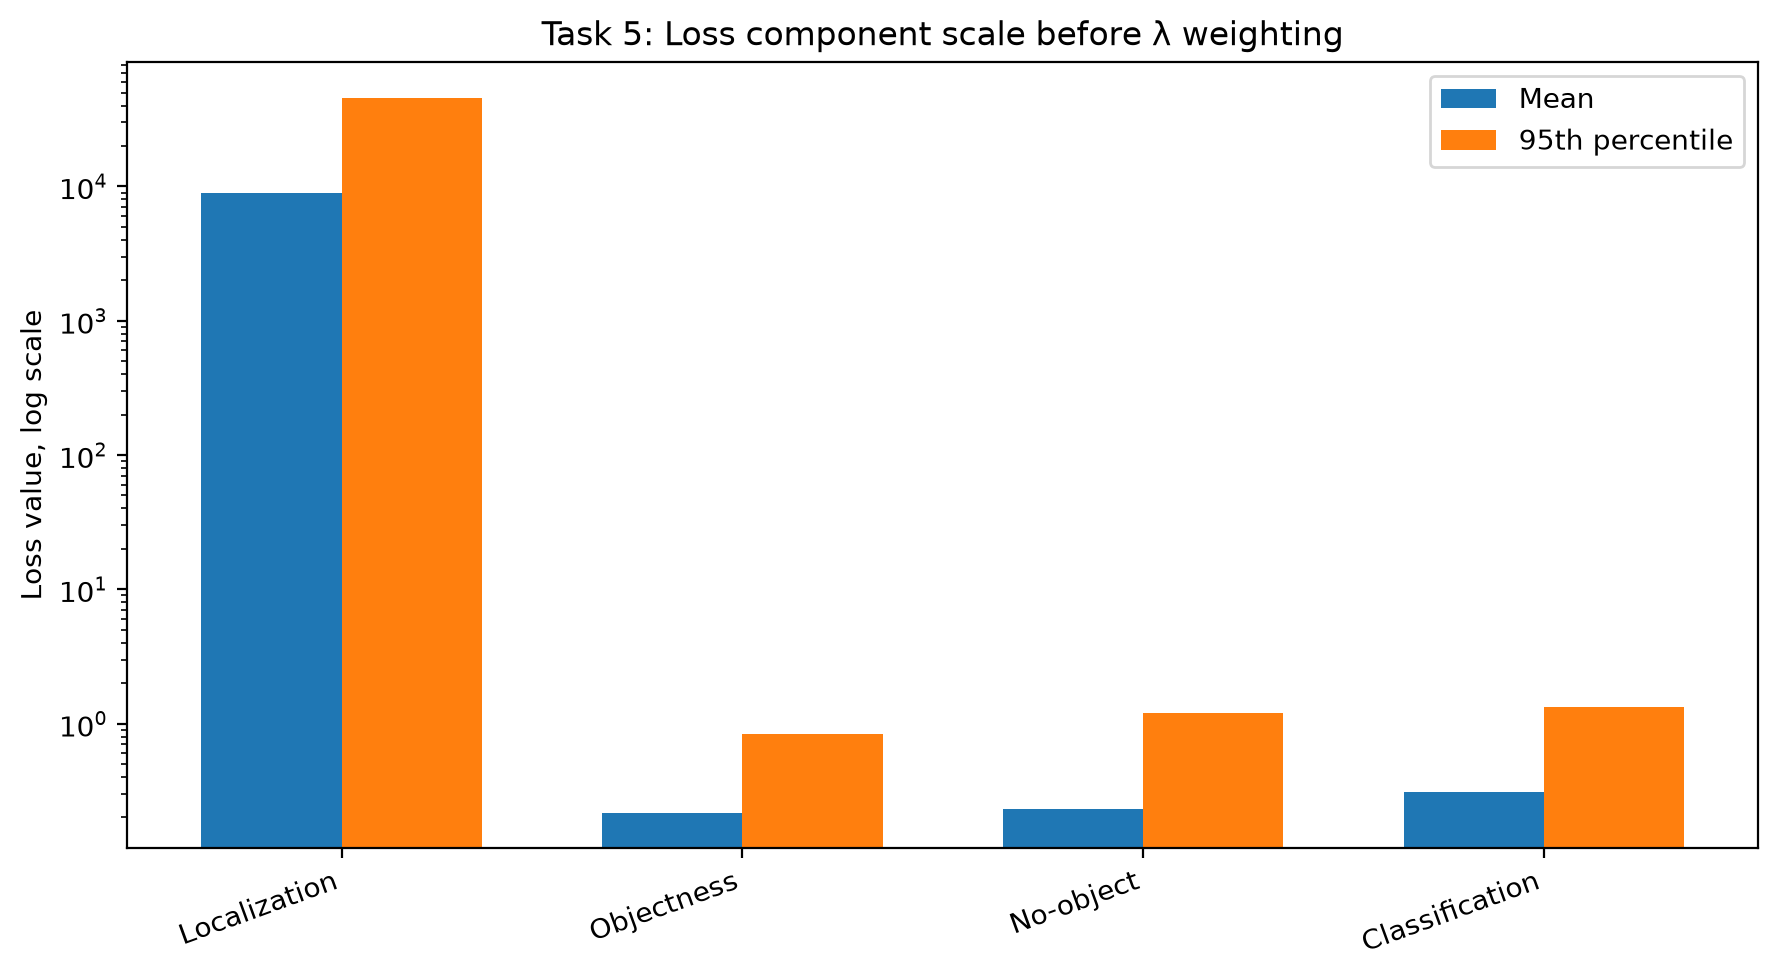

In [2]:
component_cols = [
    "loc_loss",
    "conf_loss_obj",
    "conf_loss_noobj",
    "class_loss",
    "raw_prediction_count",
    "ground_truth_count",
    "matched_prediction_count",
    "false_positive_prediction_count",
    "matched_gt_count",
    "missed_gt_count",
]

display(components[component_cols].describe().T)

display(Image(filename=str(FIG / "task5_hnm_component_scale_selected_sample.png")))


The component-scale figure shows that localization loss is several orders of magnitude larger than the other components. The mean localization loss is about 8,948.57, while the mean objectness, no-object, and classification losses are all below 0.31.

Therefore, using raw loss values makes λ configuration less meaningful unless the components are normalized or calibrated before weighting.


## λ configurations

The main λ configurations are:

| Configuration | λ_coord | λ_obj | λ_noobj | λ_cls | Intended emphasis |
|---|---:|---:|---:|---:|---|
| Balanced | 0.5 | 0.5 | 0.5 | 0.5 | Mixed hard examples |
| Localization-heavy | 2.0 | 0.5 | 0.5 | 0.5 | Poor bounding-box placement |
| Objectness-heavy | 0.5 | 2.0 | 0.5 | 0.5 | Weak confidence on matched objects |
| No-object-heavy | 0.5 | 0.5 | 2.0 | 0.5 | False-positive-heavy images |
| Classification-heavy | 0.5 | 0.5 | 0.5 | 2.0 | Class-confusion cases |


In [3]:
main_summary = summary[
    (summary["family"] == "main")
    & (summary["score_mode"].isin(["raw", "normalized"]))
].copy()

summary_cols = [
    "score_mode",
    "display_name",
    "top_n",
    "mean_num_objects",
    "mean_raw_prediction_count",
    "mean_false_positive_prediction_count",
    "mean_missed_gt_count",
    "zero_prediction_images",
    "mean_loc_loss",
    "mean_conf_loss_obj",
    "mean_conf_loss_noobj",
    "mean_class_loss",
    "dominant_Localization_share",
    "dominant_Objectness_share",
    "dominant_No-object_share",
    "dominant_Classification_share",
]

display(main_summary[summary_cols].sort_values(["score_mode", "display_name"]))


,score_mode,display_name,top_n,mean_num_objects,mean_raw_prediction_count,mean_false_positive_prediction_count,mean_missed_gt_count,zero_prediction_images,mean_loc_loss,mean_conf_loss_obj,mean_conf_loss_noobj,mean_class_loss,dominant_Localization_share,dominant_Objectness_share,dominant_No-object_share,dominant_Classification_share
0,normalized,Balanced,250,21.660,20.200,4.164,11.548,0,38337.184,1.154183,2.193421,1.944034,0.188,0.256,0.324,0.232
1,normalized,Classification-heavy,250,20.372,18.580,3.332,10.580,0,29317.712,1.149437,1.742937,2.304461,0.016,0.000,0.100,0.884
3,normalized,Localization-heavy,250,13.696,14.704,2.708,7.852,0,67506.728,0.836964,1.480025,1.412083,0.768,0.060,0.132,0.040
5,normalized,No-object-heavy,250,22.316,17.964,5.504,13.580,0,18295.508,0.892327,2.894241,1.344049,0.036,0.016,0.916,0.032
7,normalized,Objectness-heavy,250,23.140,21.800,3.784,11.540,0,31284.392,1.304157,1.957323,1.926737,0.024,0.868,0.076,0.032
9,raw,Balanced,250,1.836,7.680,0.228,0.300,0,78055.468,0.449086,0.109824,0.830125,1.000,0.000,0.000,0.000
10,raw,Classification-heavy,250,1.836,7.680,0.228,0.300,0,78055.468,0.449086,0.109824,0.830125,1.000,0.000,0.000,0.000
12,raw,Localization-heavy,250,1.836,7.680,0.228,0.300,0,78055.468,0.449086,0.109824,0.830125,1.000,0.000,0.000,0.000
14,raw,No-object-heavy,250,1.836,7.680,0.228,0.300,0,78055.468,0.449086,0.109824,0.830125,1.000,0.000,0.000,0.000
16,raw,Objectness-heavy,250,1.836,7.680,0.228,0.300,0,78055.468,0.449086,0.109824,0.830125,1.000,0.000,0.000,0.000


## Raw-loss HNM result

Using raw loss values, all five main λ configurations selected the same top-250 image set. The Jaccard overlap between every pair of configurations is 1.00.

This means that raw HNM ranking is dominated by localization loss. In this raw setting, increasing `λ_obj`, `λ_noobj`, or `λ_cls` does not materially change which images are selected.


config_b,balanced_default,localization_heavy,objectness_heavy,no_object_heavy,classification_heavy
config_a,,,,,
balanced_default,1.0,1.0,1.0,1.0,1.0
localization_heavy,1.0,1.0,1.0,1.0,1.0
objectness_heavy,1.0,1.0,1.0,1.0,1.0
no_object_heavy,1.0,1.0,1.0,1.0,1.0
classification_heavy,1.0,1.0,1.0,1.0,1.0


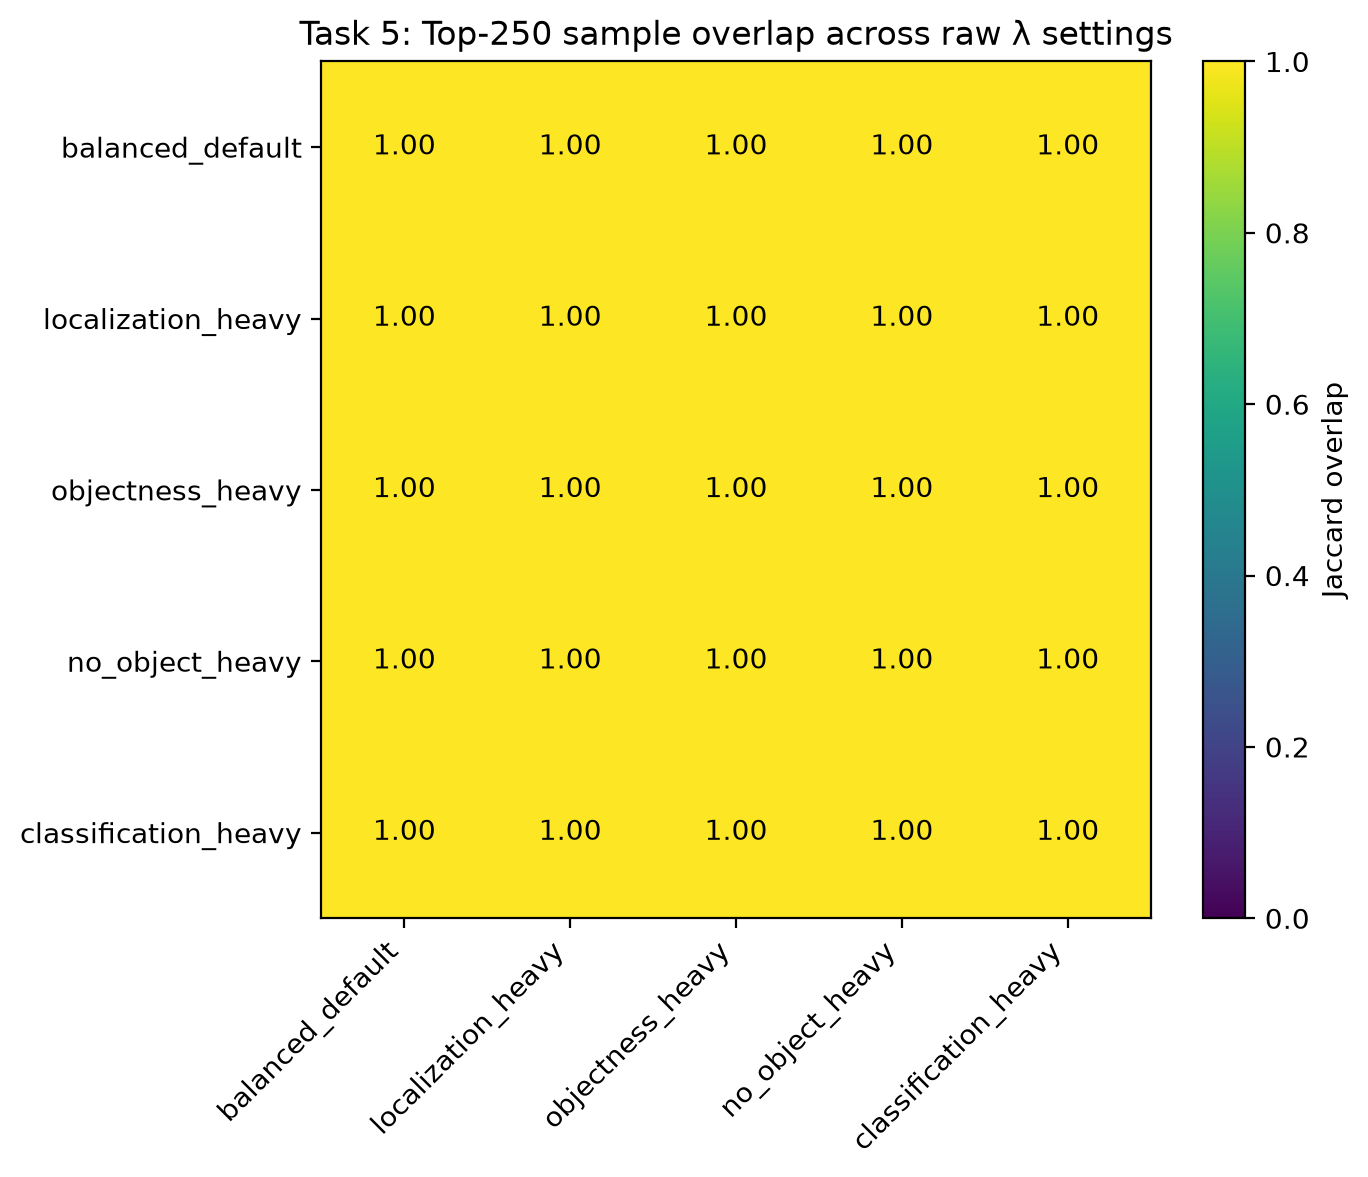

In [4]:
main_configs = [
    "balanced_default",
    "localization_heavy",
    "objectness_heavy",
    "no_object_heavy",
    "classification_heavy",
]

raw_overlap = overlap[
    (overlap["score_mode"] == "raw")
    & (overlap["config_a"].isin(main_configs))
    & (overlap["config_b"].isin(main_configs))
]

display(
    raw_overlap
    .pivot(index="config_a", columns="config_b", values="jaccard_overlap")
    .loc[main_configs, main_configs]
)

display(Image(filename=str(FIG / "task5_hnm_raw_lambda_overlap_selected_sample.png")))


## Scale-aware HNM result

To show the intended effect of the λ values, I also evaluated a scale-aware version of HNM. In this version, each component is divided by its 95th percentile before λ weighting.

This keeps one component from automatically dominating the total score because of units or scale. Under scale-aware scoring, changing λ values meaningfully changes the sampled image set.


config_b,balanced_default,localization_heavy,objectness_heavy,no_object_heavy,classification_heavy
config_a,,,,,
balanced_default,1.000000,0.392758,0.683502,0.449275,0.602564
localization_heavy,0.392758,1.000000,0.312336,0.213592,0.295337
objectness_heavy,0.683502,0.312336,1.000000,0.392758,0.582278
no_object_heavy,0.449275,0.213592,0.392758,1.000000,0.315789
classification_heavy,0.602564,0.295337,0.582278,0.315789,1.000000


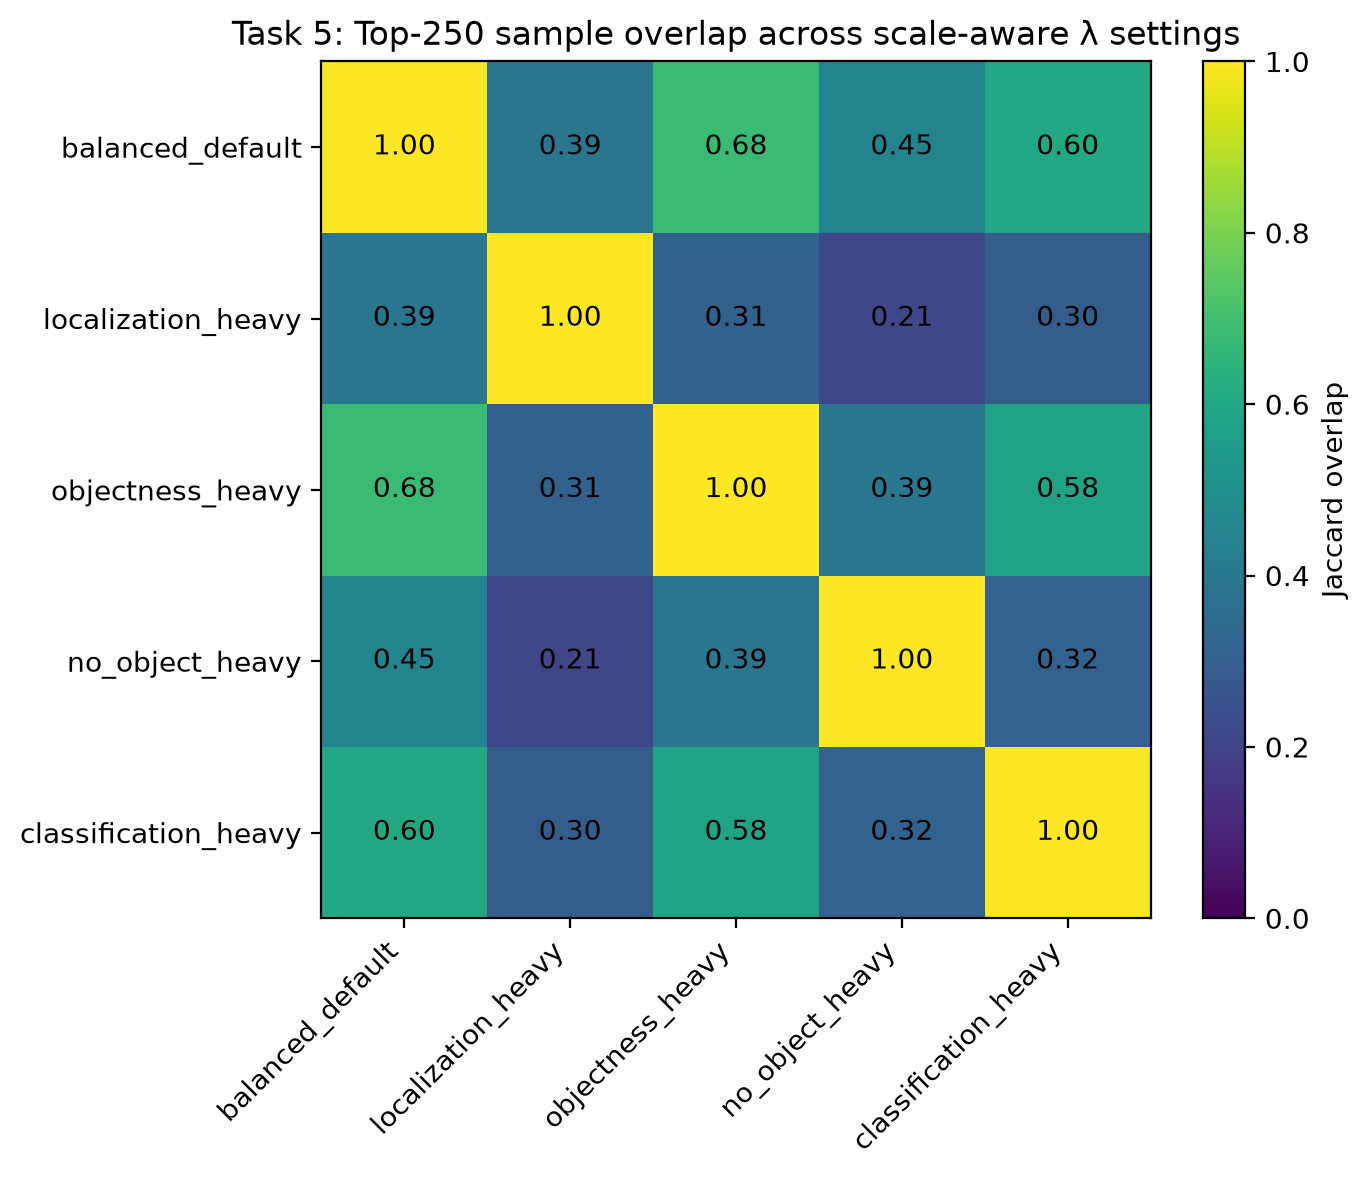

In [5]:
norm_overlap = overlap[
    (overlap["score_mode"] == "normalized")
    & (overlap["config_a"].isin(main_configs))
    & (overlap["config_b"].isin(main_configs))
]

display(
    norm_overlap
    .pivot(index="config_a", columns="config_b", values="jaccard_overlap")
    .loc[main_configs, main_configs]
)

display(Image(filename=str(FIG / "task5_hnm_normalized_lambda_overlap_selected_sample.png")))


The normalized overlap heatmap shows that λ values change the sampled image set when component scale is controlled. For example, localization-heavy and no-object-heavy sampling have low overlap, meaning they target different failure modes.


## How λ changes sampled image types

The normalized λ sweep shows the intended behavior:

- **Localization-heavy** samples images where matched detections have large box-placement errors.
- **Objectness-heavy** samples dense images where matched detections have weak confidence.
- **No-object-heavy** samples images with many false-positive predictions.
- **Classification-heavy** samples images where the model has class-confusion errors.
- **Balanced** sampling mixes these failure types.


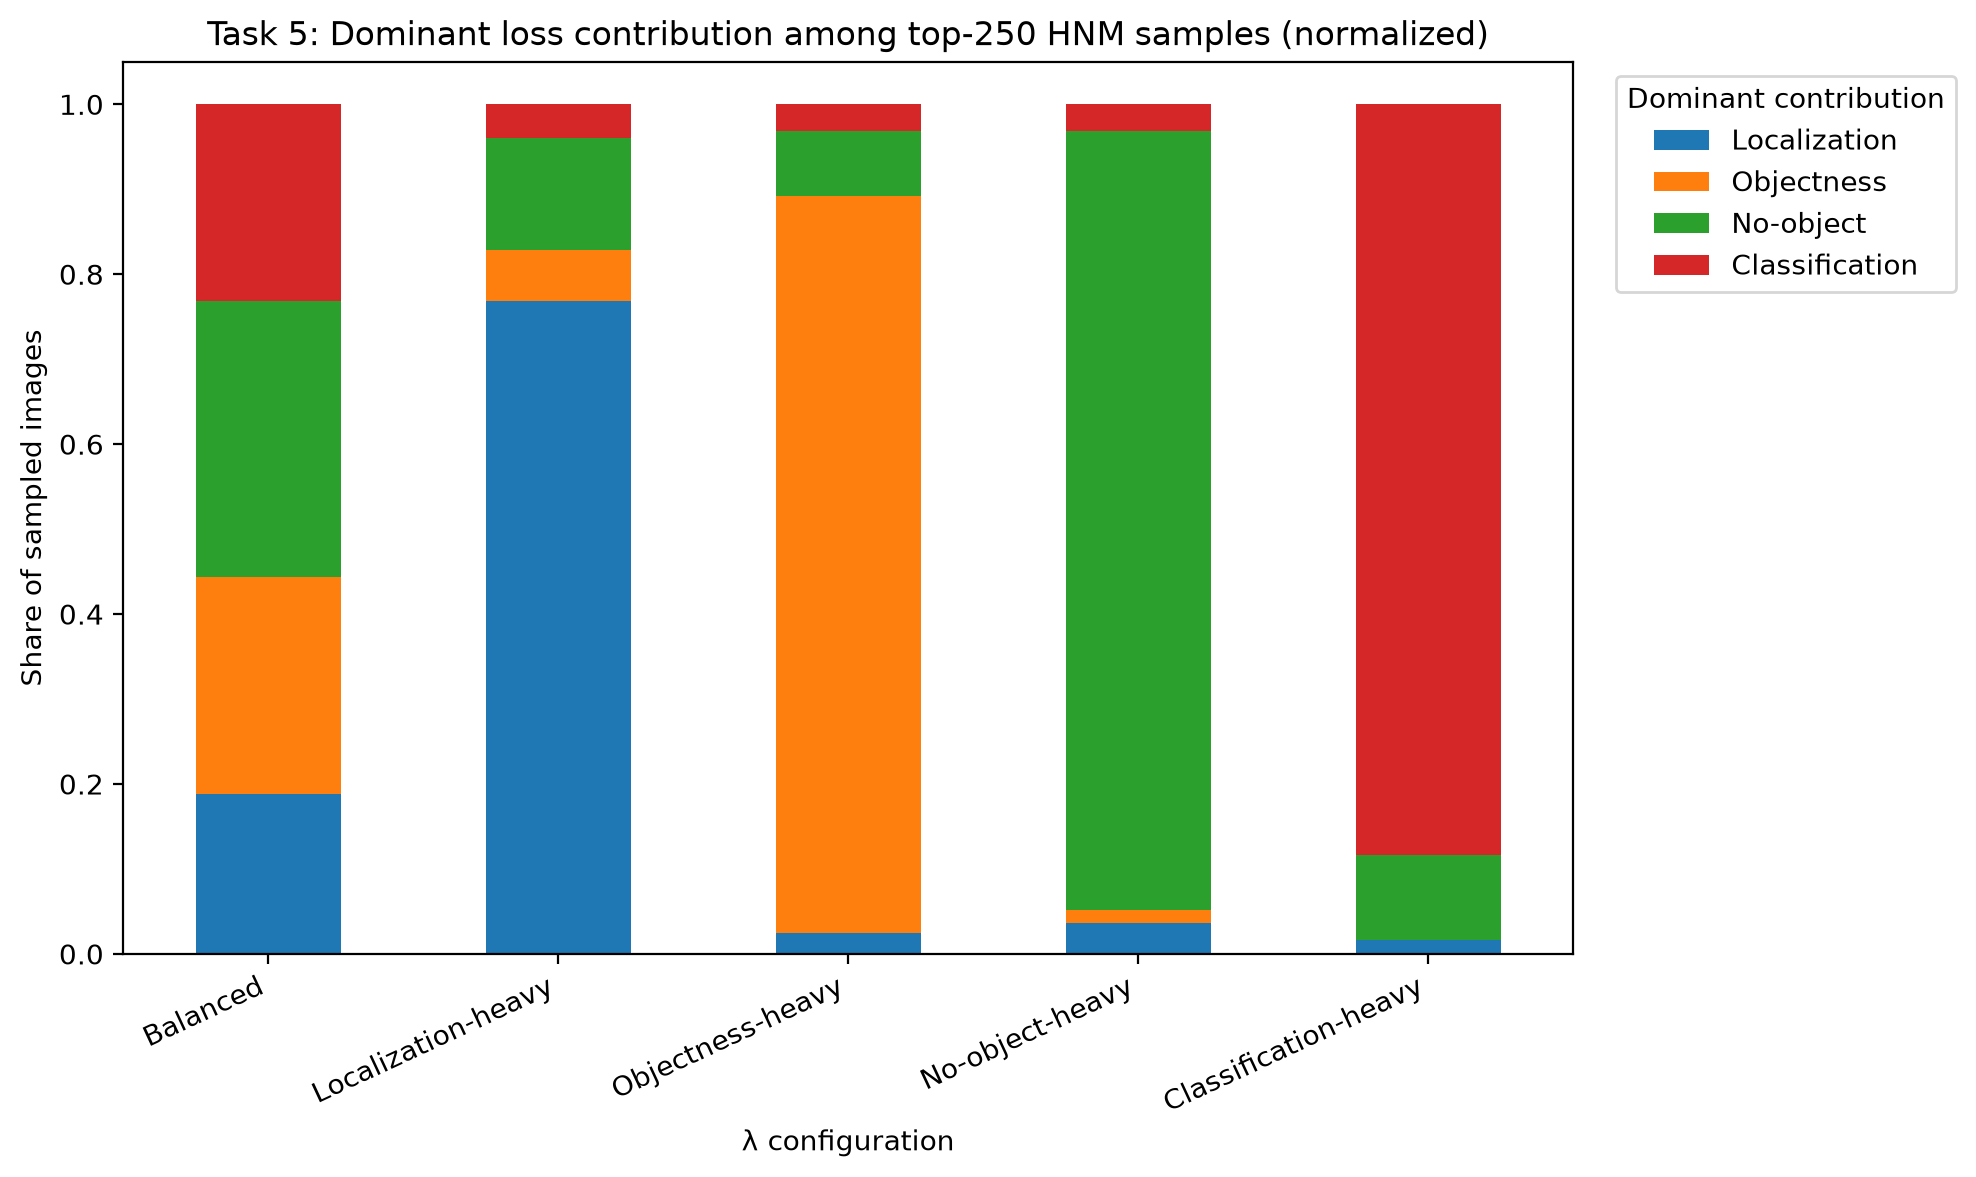

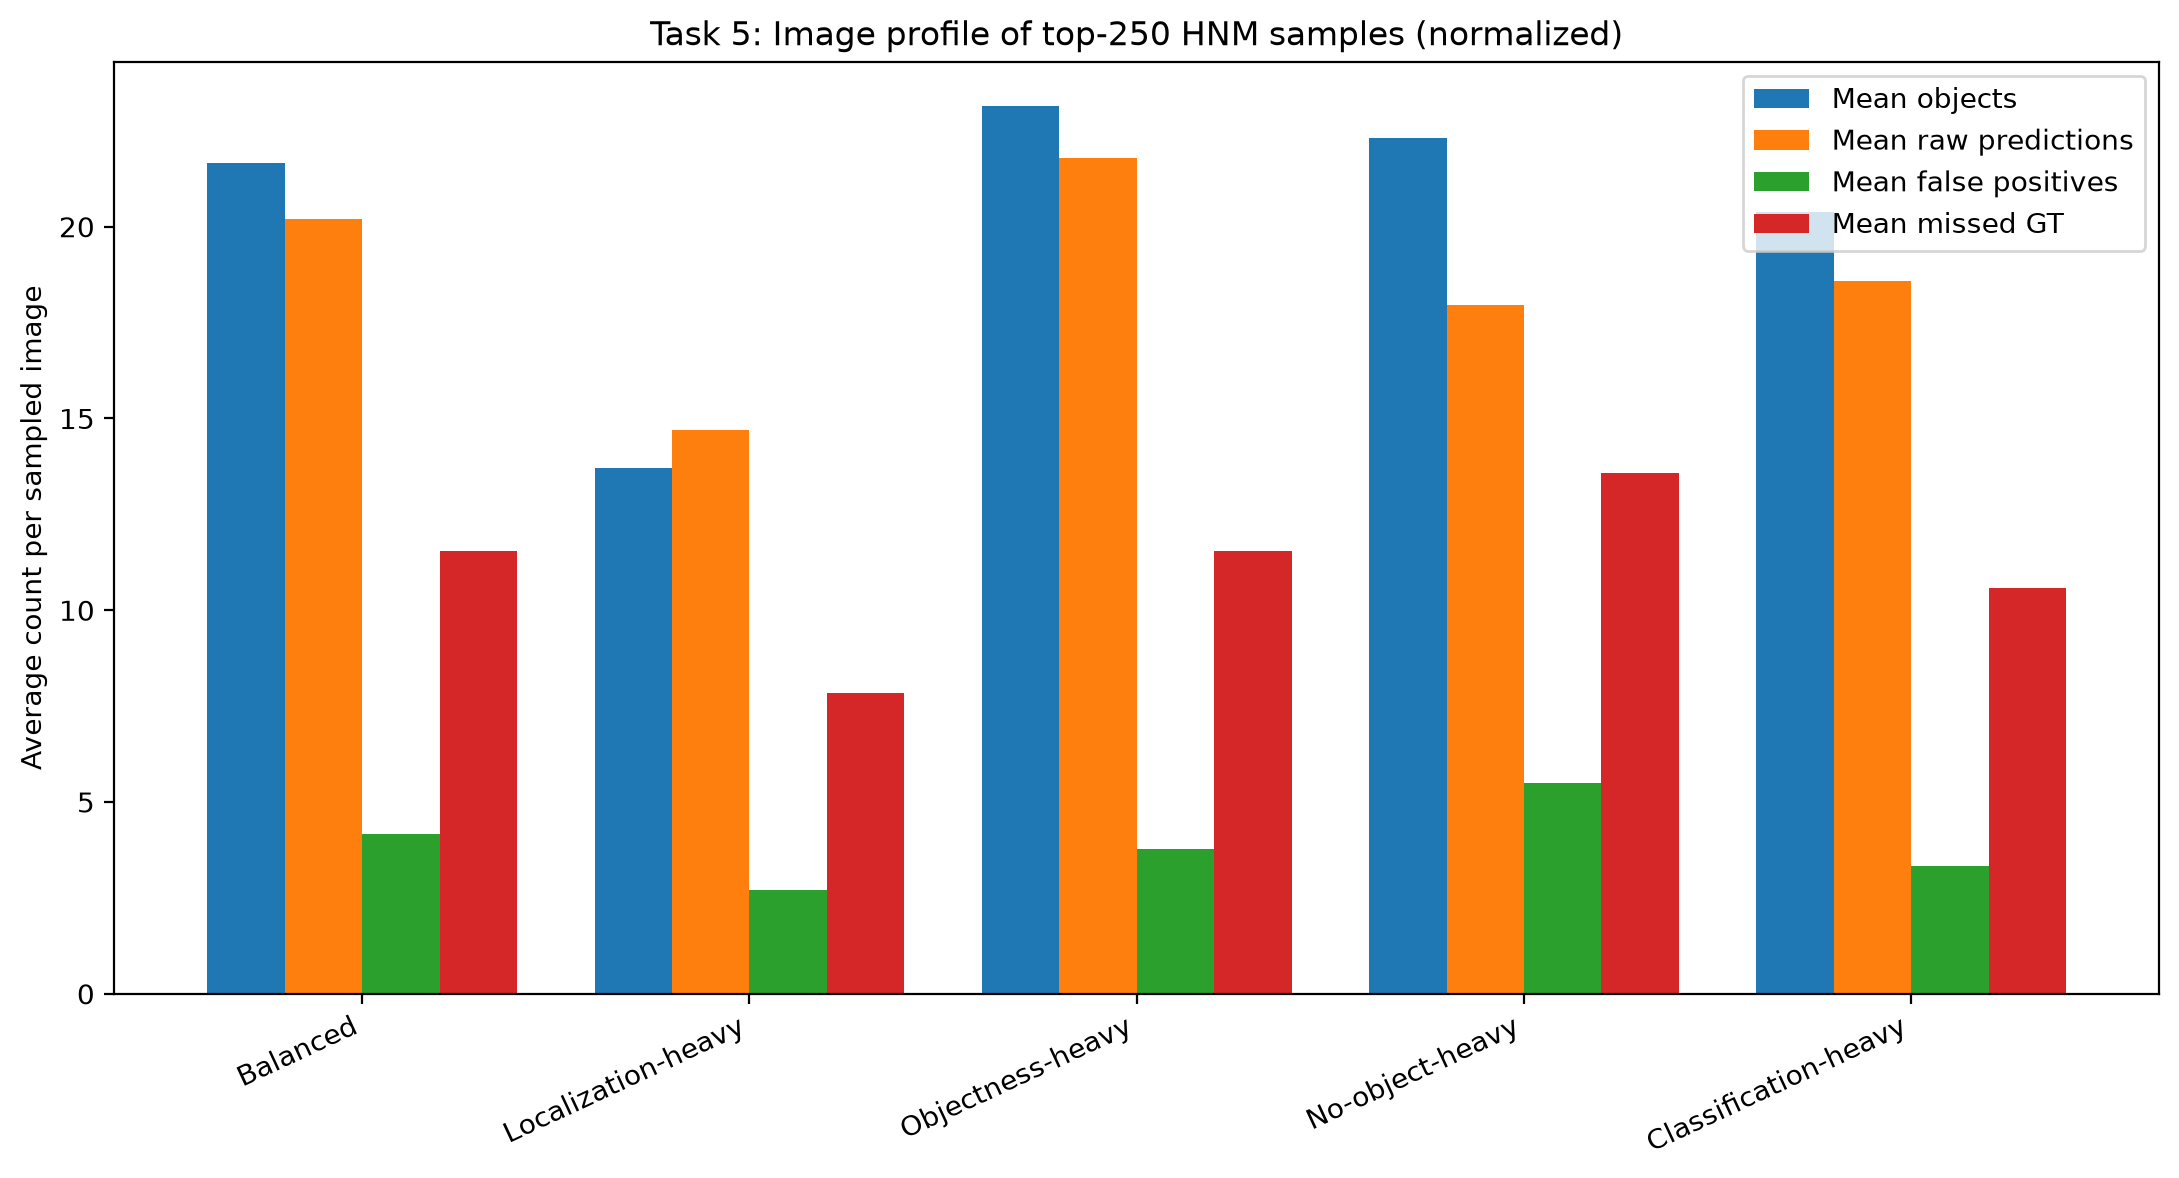

In [6]:
display(Image(filename=str(FIG / "task5_hnm_dominant_component_by_lambda_normalized_selected_sample.png")))
display(Image(filename=str(FIG / "task5_hnm_image_profile_by_lambda_normalized_selected_sample.png")))


The dominant-component figure is the clearest evidence that the λ parameters control the HNM emphasis. Localization-heavy sampling is mostly dominated by localization contribution, objectness-heavy sampling by objectness contribution, no-object-heavy sampling by no-object contribution, and classification-heavy sampling by classification contribution.

The image-profile figure shows that these settings also change the types of scenes sampled. No-object-heavy sampling produces the highest false-positive count, while objectness-heavy and classification-heavy settings tend to select dense scenes with many predictions.


## Density and class composition

The λ settings also change the visual structure and semantic composition of sampled images.


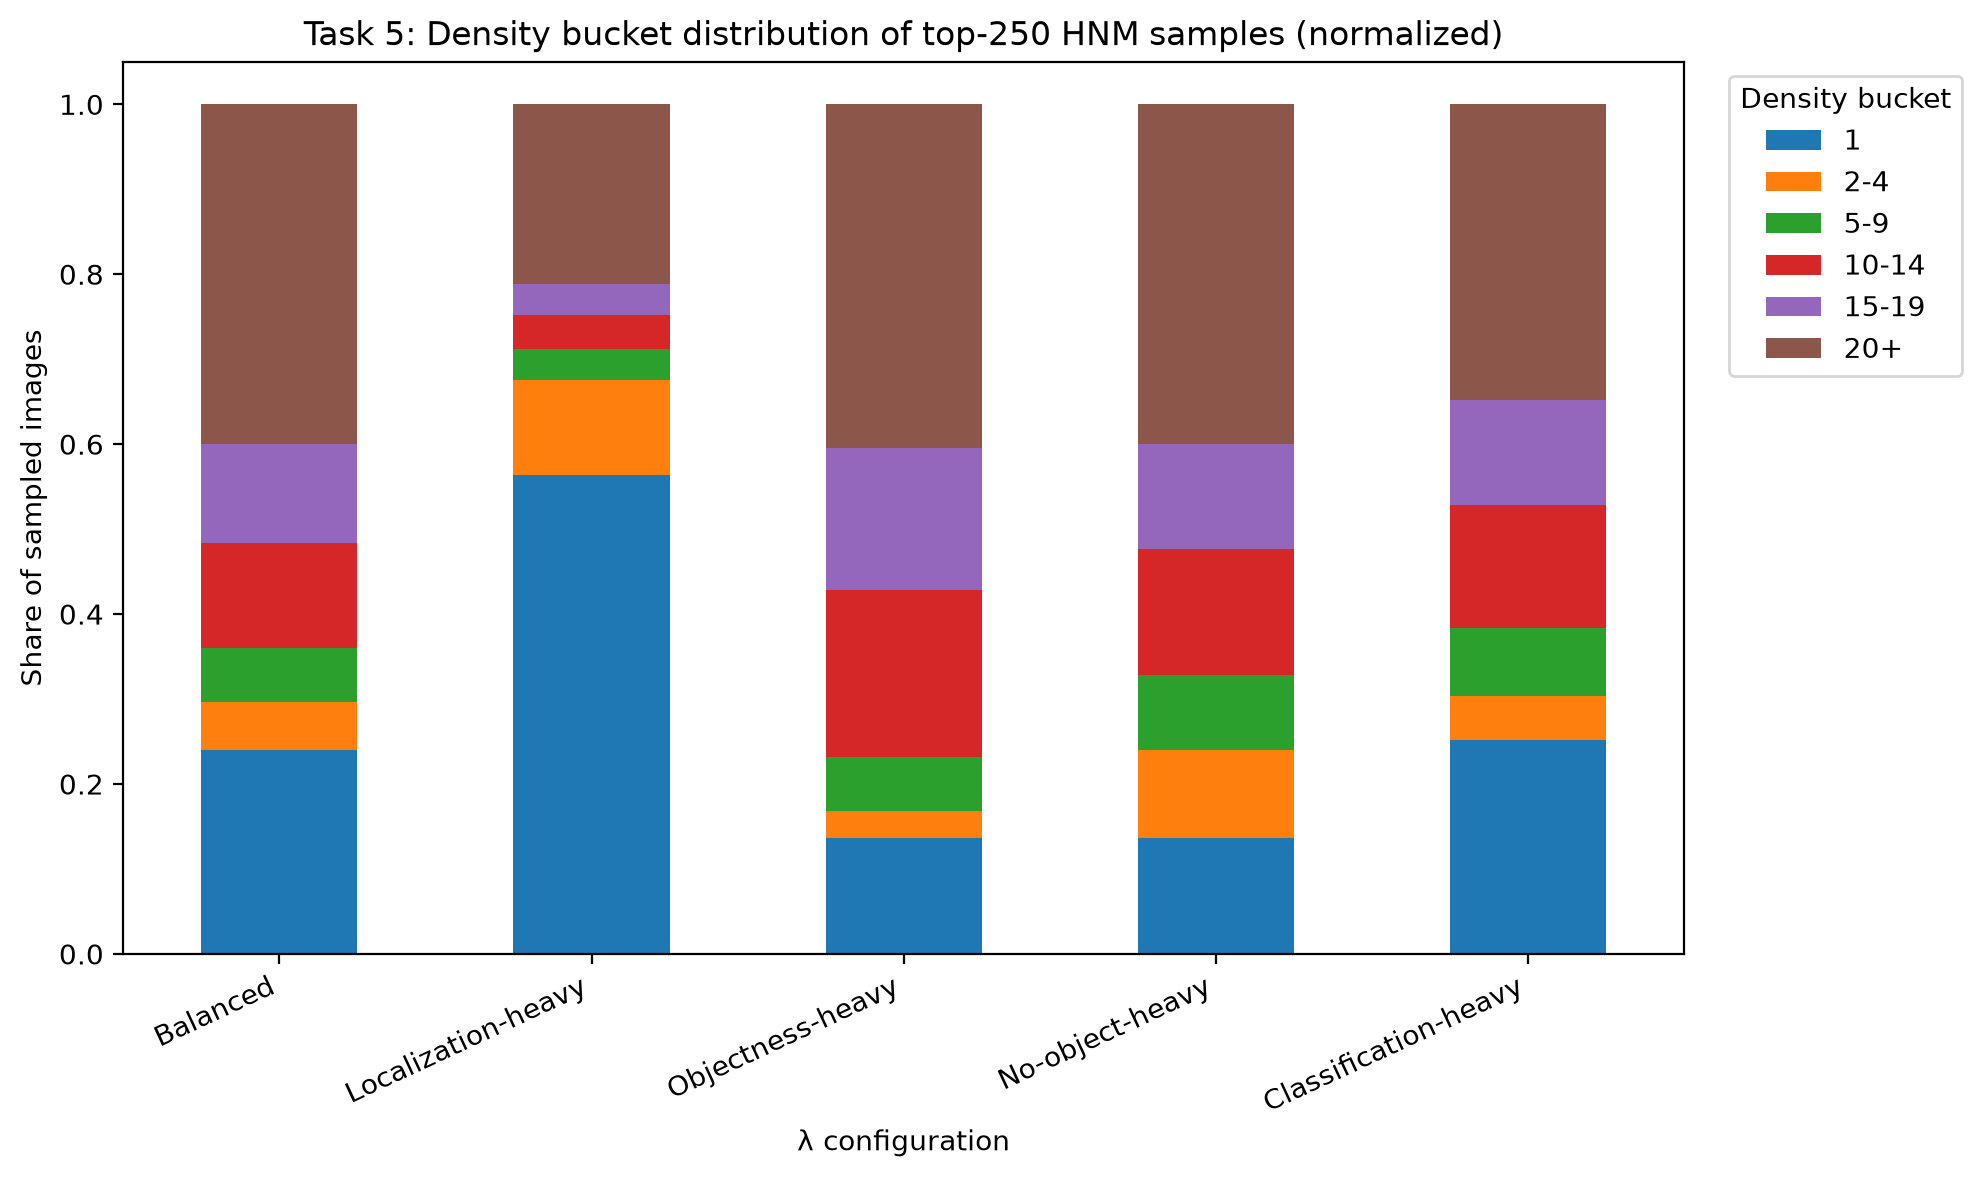

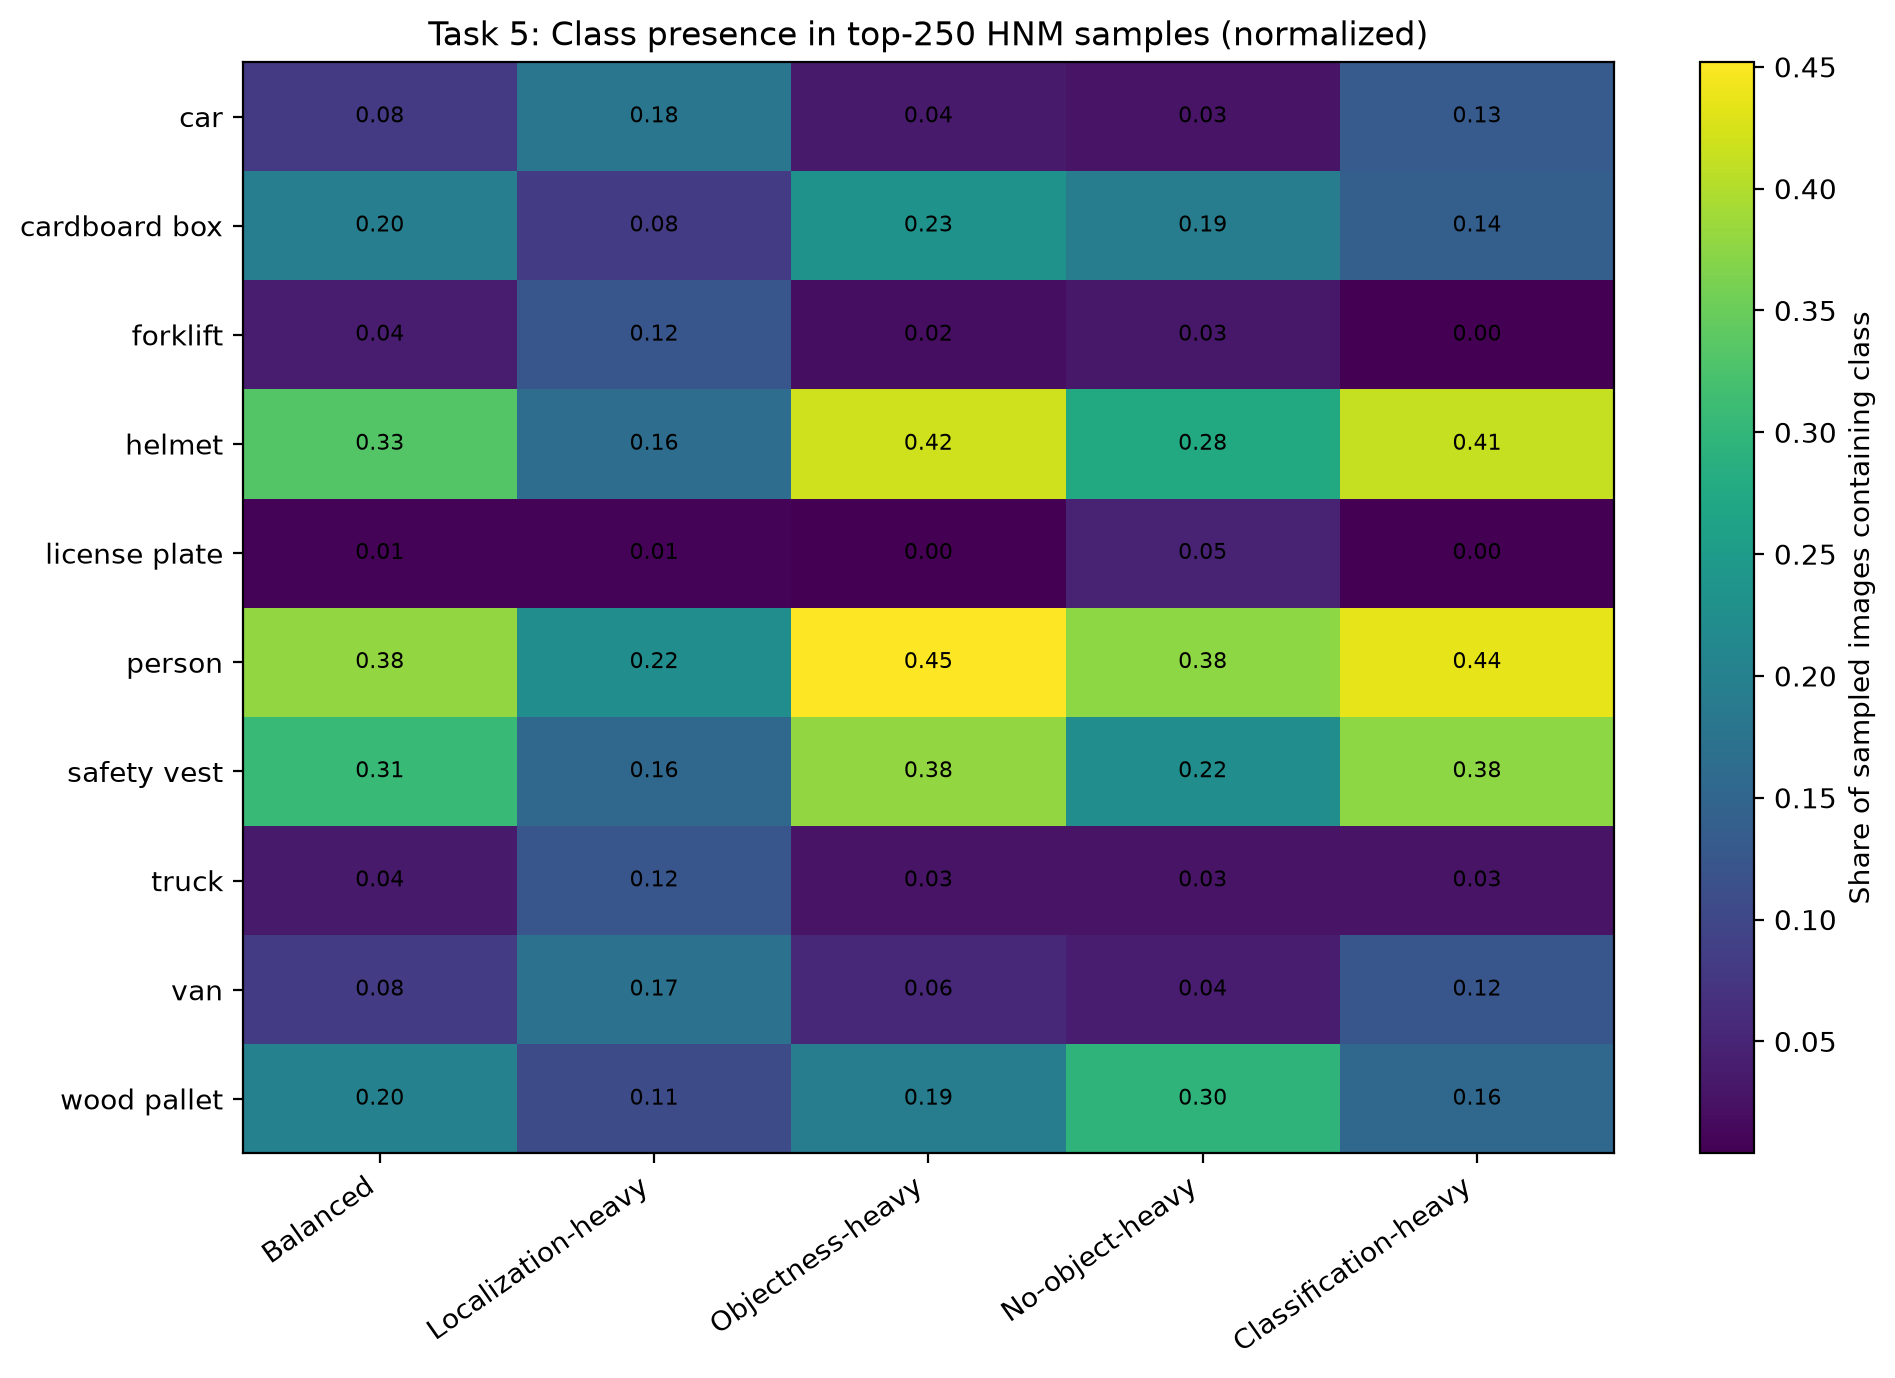

In [7]:
display(Image(filename=str(FIG / "task5_hnm_density_distribution_by_lambda_normalized_selected_sample.png")))
display(Image(filename=str(FIG / "task5_hnm_class_presence_by_lambda_normalized_selected_sample.png")))


The density distribution shows that localization-heavy sampling favors more single-object images, while objectness-heavy and no-object-heavy settings shift toward dense images. The class-presence heatmap shows that objectness-heavy and classification-heavy settings emphasize PPE/person scenes, while no-object-heavy sampling includes more dense pallet scenes.


## Zero-prediction limitation

The implemented HNM loss is prediction-based. Images with no raw predictions receive zero localization, objectness, no-object, and classification loss, even if they contain ground-truth objects.

This is an important limitation. The current HNM method is useful for mining bad detections, false positives, weak objectness, poor localization, and class confusion. It is not sufficient by itself for false-negative mining where the detector misses all objects.


In [8]:
zero_pred = components[components["raw_prediction_count"] == 0]

print("Zero-prediction images:", len(zero_pred))
print("Mean GT objects in zero-prediction images:", zero_pred["ground_truth_count"].mean())
print("Median GT objects in zero-prediction images:", zero_pred["ground_truth_count"].median())
print("Max GT objects in zero-prediction images:", zero_pred["ground_truth_count"].max())

display(
    main_summary[
        ["score_mode", "display_name", "zero_prediction_images"]
    ].sort_values(["score_mode", "display_name"])
)


Zero-prediction images: 943
Mean GT objects in zero-prediction images: 2.4846235418875926
Median GT objects in zero-prediction images: 2.0
Max GT objects in zero-prediction images: 15


,score_mode,display_name,zero_prediction_images
0,normalized,Balanced,0
1,normalized,Classification-heavy,0
3,normalized,Localization-heavy,0
5,normalized,No-object-heavy,0
7,normalized,Objectness-heavy,0
9,raw,Balanced,0
10,raw,Classification-heavy,0
12,raw,Localization-heavy,0
14,raw,No-object-heavy,0
16,raw,Objectness-heavy,0


## Conclusion

The raw HNM sweep shows that λ configuration alone is not enough when the loss components have very different numeric scales. Because localization loss is measured in squared pixel-coordinate units, raw HNM rankings were dominated by localization and all main λ settings selected the same top-250 image set.

The scale-aware sweep demonstrates the intended role of each λ parameter. Increasing `λ_coord` selects poor-localization images, increasing `λ_obj` selects weak matched detections, increasing `λ_noobj` selects false-positive-heavy images, and increasing `λ_cls` selects class-confusion cases.

Therefore, λ values directly control the failure mode emphasized by HNM, but component normalization or calibration is needed for those weights to behave as intended.


## Appendix: Reproducibility Scripts

The following scripts were used to generate the Task 5 HNM component table, lambda-sweep summaries, and figures. They are included here for reproducibility and to distinguish the analysis workflow from the submitted implementation modules.


### `analysis/task5_build_hnm_components.py`

~~~python
from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path.cwd()
OUT = ROOT / "analysis" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

SAMPLE_PATH = OUT / "task2_selected_sample_index.csv"
RAW_PRED_PATH = OUT / "task3_nts_model2_raw_predictions_selected_sample.csv"
GT_PATH = OUT / "task3_nts_ground_truth_selected_sample.csv"

COMPONENT_PATH = OUT / "task5_hnm_image_loss_components_selected_sample.csv"

IOU_THRESHOLD = 0.5
NUM_CLASSES = 20


def xywh_to_xyxy_array(df):
    if df is None or len(df) == 0:
        return np.empty((0, 4), dtype=float)

    x1 = df["bbox_x"].astype(float).to_numpy()
    y1 = df["bbox_y"].astype(float).to_numpy()
    x2 = x1 + df["bbox_w"].astype(float).to_numpy()
    y2 = y1 + df["bbox_h"].astype(float).to_numpy()

    return np.stack([x1, y1, x2, y2], axis=1)


def iou_xyxy_one_to_many(box, boxes):
    if boxes.size == 0:
        return np.empty((0,), dtype=float)

    ax1, ay1, ax2, ay2 = box

    bx1 = boxes[:, 0]
    by1 = boxes[:, 1]
    bx2 = boxes[:, 2]
    by2 = boxes[:, 3]

    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    intersection = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = np.maximum(0.0, bx2 - bx1) * np.maximum(0.0, by2 - by1)

    union = area_a + area_b - intersection
    return np.where(union > 0, intersection / union, 0.0)


def parse_class_scores(value):
    if isinstance(value, str):
        scores = json.loads(value)
    else:
        scores = []

    if len(scores) < NUM_CLASSES:
        scores = scores + [0.0] * (NUM_CLASSES - len(scores))
    elif len(scores) > NUM_CLASSES:
        scores = scores[:NUM_CLASSES]

    return np.asarray(scores, dtype=float)


def compute_image_components(image_row, pred_group, gt_group):
    loc_loss = 0.0
    conf_loss_obj = 0.0
    conf_loss_noobj = 0.0
    class_loss = 0.0

    raw_prediction_count = 0 if pred_group is None else len(pred_group)
    gt_count = 0 if gt_group is None else len(gt_group)

    matched_prediction_count = 0
    false_positive_prediction_count = 0
    matched_gt_indices = set()

    if pred_group is None or len(pred_group) == 0:
        return {
            "loc_loss": 0.0,
            "conf_loss_obj": 0.0,
            "conf_loss_noobj": 0.0,
            "class_loss": 0.0,
            "raw_prediction_count": 0,
            "ground_truth_count": gt_count,
            "matched_prediction_count": 0,
            "false_positive_prediction_count": 0,
            "matched_gt_count": 0,
            "missed_gt_count": gt_count,
        }

    pred_boxes = xywh_to_xyxy_array(pred_group)
    pred_objectness = pred_group["object_score"].astype(float).to_numpy()
    pred_class_scores = [parse_class_scores(v) for v in pred_group["class_scores_json"].tolist()]

    if gt_group is None or len(gt_group) == 0:
        conf_loss_noobj = float(np.sum(pred_objectness ** 2))
        return {
            "loc_loss": 0.0,
            "conf_loss_obj": 0.0,
            "conf_loss_noobj": conf_loss_noobj,
            "class_loss": 0.0,
            "raw_prediction_count": raw_prediction_count,
            "ground_truth_count": 0,
            "matched_prediction_count": 0,
            "false_positive_prediction_count": raw_prediction_count,
            "matched_gt_count": 0,
            "missed_gt_count": 0,
        }

    gt_boxes = xywh_to_xyxy_array(gt_group)
    gt_classes = gt_group["class_id"].astype(int).to_numpy()

    for pred_idx in range(len(pred_group)):
        pred_box = pred_boxes[pred_idx]
        objectness = float(pred_objectness[pred_idx])
        class_scores = pred_class_scores[pred_idx]

        ious = iou_xyxy_one_to_many(pred_box, gt_boxes)

        if len(ious) == 0:
            conf_loss_noobj += objectness ** 2
            false_positive_prediction_count += 1
            continue

        best_gt_idx = int(np.argmax(ious))
        best_iou = float(ious[best_gt_idx])

        if best_iou >= IOU_THRESHOLD:
            target_box = gt_boxes[best_gt_idx]
            target_class = int(gt_classes[best_gt_idx])

            loc_loss += float(np.sum((pred_box - target_box) ** 2))
            conf_loss_obj += float((1.0 - objectness) ** 2)

            correct_class_score = float(class_scores[target_class]) if 0 <= target_class < len(class_scores) else 0.0
            class_loss += float((1.0 - correct_class_score) ** 2)

            matched_prediction_count += 1
            matched_gt_indices.add(best_gt_idx)
        else:
            conf_loss_noobj += float(objectness ** 2)
            false_positive_prediction_count += 1

    matched_gt_count = len(matched_gt_indices)
    missed_gt_count = max(0, gt_count - matched_gt_count)

    return {
        "loc_loss": loc_loss,
        "conf_loss_obj": conf_loss_obj,
        "conf_loss_noobj": conf_loss_noobj,
        "class_loss": class_loss,
        "raw_prediction_count": raw_prediction_count,
        "ground_truth_count": gt_count,
        "matched_prediction_count": matched_prediction_count,
        "false_positive_prediction_count": false_positive_prediction_count,
        "matched_gt_count": matched_gt_count,
        "missed_gt_count": missed_gt_count,
    }


def main():
    sample = pd.read_csv(SAMPLE_PATH)
    raw = pd.read_csv(RAW_PRED_PATH)
    gt = pd.read_csv(GT_PATH)

    pred_groups = {k: v for k, v in raw.groupby("image_path")} if len(raw) else {}
    gt_groups = {k: v for k, v in gt.groupby("image_path")} if len(gt) else {}

    rows = []

    for i, (_, image_row) in enumerate(sample.iterrows(), start=1):
        image_path = image_row["image_path"]
        pred_group = pred_groups.get(image_path)
        gt_group = gt_groups.get(image_path)

        components = compute_image_components(image_row, pred_group, gt_group)

        rows.append({
            "image_file": image_row["image_file"],
            "image_path": image_row["image_path"],
            "num_objects": int(image_row["num_objects"]),
            "density_bucket": image_row["density_bucket"],
            "class_names_present": image_row["class_names_present"],
            **components,
        })

        if i % 1000 == 0:
            print(f"[COMPONENTS] processed {i}/{len(sample)} images")

    df = pd.DataFrame(rows)
    df.to_csv(COMPONENT_PATH, index=False)

    print()
    print("[WRITE]", COMPONENT_PATH)
    print("shape:", df.shape)

    print()
    print("=" * 100)
    print("COMPONENT SCALE SUMMARY")
    print("=" * 100)

    component_cols = [
        "loc_loss",
        "conf_loss_obj",
        "conf_loss_noobj",
        "class_loss",
        "raw_prediction_count",
        "ground_truth_count",
        "matched_prediction_count",
        "false_positive_prediction_count",
        "matched_gt_count",
        "missed_gt_count",
    ]

    print(df[component_cols].describe().T.to_string())

    print()
    print("=" * 100)
    print("NONZERO COUNTS")
    print("=" * 100)
    for col in ["loc_loss", "conf_loss_obj", "conf_loss_noobj", "class_loss"]:
        print(f"{col:20s}", int((df[col] > 0).sum()))

    print()
    print("=" * 100)
    print("ZERO-PREDICTION IMAGES")
    print("=" * 100)
    zero_pred = df[df["raw_prediction_count"] == 0]
    print("count:", len(zero_pred))
    print("mean GT objects:", zero_pred["ground_truth_count"].mean())
    print("median GT objects:", zero_pred["ground_truth_count"].median())
    print("max GT objects:", zero_pred["ground_truth_count"].max())

    print()
    print("=" * 100)
    print("TOP 10 BY EACH RAW COMPONENT")
    print("=" * 100)

    for col in ["loc_loss", "conf_loss_obj", "conf_loss_noobj", "class_loss", "missed_gt_count"]:
        print()
        print(f"--- Top 10 by {col} ---")
        top = df.sort_values(col, ascending=False).head(10)
        print(top[[
            "image_file",
            "density_bucket",
            "num_objects",
            "raw_prediction_count",
            "matched_prediction_count",
            "false_positive_prediction_count",
            "matched_gt_count",
            "missed_gt_count",
            "loc_loss",
            "conf_loss_obj",
            "conf_loss_noobj",
            "class_loss",
            "class_names_present",
        ]].to_string(index=False))


if __name__ == "__main__":
    main()

~~~


### `analysis/task5_hnm_lambda_sweep.py`

~~~python
from pathlib import Path
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1]
OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

COMPONENT_PATH = OUT / "task5_hnm_image_loss_components_selected_sample.csv"

TOP_N = 250

COMPONENTS = [
    "loc_loss",
    "conf_loss_obj",
    "conf_loss_noobj",
    "class_loss",
]

COMPONENT_LABELS = {
    "loc_loss": "Localization",
    "conf_loss_obj": "Objectness",
    "conf_loss_noobj": "No-object",
    "class_loss": "Classification",
}

CONFIGS = [
    {
        "config_name": "balanced_default",
        "display_name": "Balanced",
        "lambda_coord": 0.5,
        "lambda_obj": 0.5,
        "lambda_noobj": 0.5,
        "lambda_cls": 0.5,
        "family": "main",
    },
    {
        "config_name": "localization_heavy",
        "display_name": "Localization-heavy",
        "lambda_coord": 2.0,
        "lambda_obj": 0.5,
        "lambda_noobj": 0.5,
        "lambda_cls": 0.5,
        "family": "main",
    },
    {
        "config_name": "objectness_heavy",
        "display_name": "Objectness-heavy",
        "lambda_coord": 0.5,
        "lambda_obj": 2.0,
        "lambda_noobj": 0.5,
        "lambda_cls": 0.5,
        "family": "main",
    },
    {
        "config_name": "no_object_heavy",
        "display_name": "No-object-heavy",
        "lambda_coord": 0.5,
        "lambda_obj": 0.5,
        "lambda_noobj": 2.0,
        "lambda_cls": 0.5,
        "family": "main",
    },
    {
        "config_name": "classification_heavy",
        "display_name": "Classification-heavy",
        "lambda_coord": 0.5,
        "lambda_obj": 0.5,
        "lambda_noobj": 0.5,
        "lambda_cls": 2.0,
        "family": "main",
    },
    {
        "config_name": "localization_only",
        "display_name": "Localization-only",
        "lambda_coord": 1.0,
        "lambda_obj": 0.0,
        "lambda_noobj": 0.0,
        "lambda_cls": 0.0,
        "family": "component_only",
    },
    {
        "config_name": "objectness_only",
        "display_name": "Objectness-only",
        "lambda_coord": 0.0,
        "lambda_obj": 1.0,
        "lambda_noobj": 0.0,
        "lambda_cls": 0.0,
        "family": "component_only",
    },
    {
        "config_name": "no_object_only",
        "display_name": "No-object-only",
        "lambda_coord": 0.0,
        "lambda_obj": 0.0,
        "lambda_noobj": 1.0,
        "lambda_cls": 0.0,
        "family": "component_only",
    },
    {
        "config_name": "classification_only",
        "display_name": "Classification-only",
        "lambda_coord": 0.0,
        "lambda_obj": 0.0,
        "lambda_noobj": 0.0,
        "lambda_cls": 1.0,
        "family": "component_only",
    },
]


def parse_class_names(value):
    if isinstance(value, list):
        return value
    if not isinstance(value, str) or not value.strip():
        return []
    try:
        parsed = json.loads(value)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [str(x) for x in parsed]
    except Exception:
        pass
    return [value]


def weighted_score(df, cfg, mode, scales):
    if mode == "raw":
        loc = df["loc_loss"]
        obj = df["conf_loss_obj"]
        noobj = df["conf_loss_noobj"]
        cls = df["class_loss"]
    elif mode == "normalized":
        loc = df["loc_loss"] / scales["loc_loss"]
        obj = df["conf_loss_obj"] / scales["conf_loss_obj"]
        noobj = df["conf_loss_noobj"] / scales["conf_loss_noobj"]
        cls = df["class_loss"] / scales["class_loss"]
    else:
        raise ValueError(mode)

    return (
        cfg["lambda_coord"] * loc
        + cfg["lambda_obj"] * obj
        + cfg["lambda_noobj"] * noobj
        + cfg["lambda_cls"] * cls
    )


def contribution_columns(df, cfg, mode, scales):
    if mode == "raw":
        base = {
            "loc_loss": df["loc_loss"],
            "conf_loss_obj": df["conf_loss_obj"],
            "conf_loss_noobj": df["conf_loss_noobj"],
            "class_loss": df["class_loss"],
        }
    else:
        base = {
            "loc_loss": df["loc_loss"] / scales["loc_loss"],
            "conf_loss_obj": df["conf_loss_obj"] / scales["conf_loss_obj"],
            "conf_loss_noobj": df["conf_loss_noobj"] / scales["conf_loss_noobj"],
            "class_loss": df["class_loss"] / scales["class_loss"],
        }

    contrib = pd.DataFrame({
        "contrib_loc": cfg["lambda_coord"] * base["loc_loss"],
        "contrib_obj": cfg["lambda_obj"] * base["conf_loss_obj"],
        "contrib_noobj": cfg["lambda_noobj"] * base["conf_loss_noobj"],
        "contrib_cls": cfg["lambda_cls"] * base["class_loss"],
    })

    labels = {
        "contrib_loc": "Localization",
        "contrib_obj": "Objectness",
        "contrib_noobj": "No-object",
        "contrib_cls": "Classification",
    }

    dominant = contrib.idxmax(axis=1).map(labels)
    return contrib, dominant


def build_top_samples(df, scales):
    rows = []

    for mode in ["raw", "normalized"]:
        for cfg in CONFIGS:
            scored = df.copy()
            scored["score_mode"] = mode
            scored["config_name"] = cfg["config_name"]
            scored["display_name"] = cfg["display_name"]
            scored["family"] = cfg["family"]
            scored["lambda_coord"] = cfg["lambda_coord"]
            scored["lambda_obj"] = cfg["lambda_obj"]
            scored["lambda_noobj"] = cfg["lambda_noobj"]
            scored["lambda_cls"] = cfg["lambda_cls"]
            scored["hnm_score"] = weighted_score(scored, cfg, mode, scales)

            contrib, dominant = contribution_columns(scored, cfg, mode, scales)
            scored = pd.concat([scored, contrib], axis=1)
            scored["dominant_contribution"] = dominant

            scored = scored.sort_values(
                ["hnm_score", "image_file"],
                ascending=[False, True]
            ).head(TOP_N).copy()

            scored["rank"] = np.arange(1, len(scored) + 1)

            rows.append(scored)

    return pd.concat(rows, axis=0, ignore_index=True)


def summarize_top(top_df):
    summary_rows = []

    group_cols = [
        "score_mode",
        "config_name",
        "display_name",
        "family",
        "lambda_coord",
        "lambda_obj",
        "lambda_noobj",
        "lambda_cls",
    ]

    for keys, group in top_df.groupby(group_cols, dropna=False):
        d = dict(zip(group_cols, keys))

        row = {
            **d,
            "top_n": len(group),
            "mean_hnm_score": group["hnm_score"].mean(),
            "median_hnm_score": group["hnm_score"].median(),
            "mean_num_objects": group["num_objects"].mean(),
            "median_num_objects": group["num_objects"].median(),
            "mean_raw_prediction_count": group["raw_prediction_count"].mean(),
            "mean_matched_prediction_count": group["matched_prediction_count"].mean(),
            "mean_false_positive_prediction_count": group["false_positive_prediction_count"].mean(),
            "mean_missed_gt_count": group["missed_gt_count"].mean(),
            "zero_prediction_images": int((group["raw_prediction_count"] == 0).sum()),
            "share_zero_prediction_images": float((group["raw_prediction_count"] == 0).mean()),
            "mean_loc_loss": group["loc_loss"].mean(),
            "mean_conf_loss_obj": group["conf_loss_obj"].mean(),
            "mean_conf_loss_noobj": group["conf_loss_noobj"].mean(),
            "mean_class_loss": group["class_loss"].mean(),
        }

        for component in ["Localization", "Objectness", "No-object", "Classification"]:
            row[f"dominant_{component}_share"] = float((group["dominant_contribution"] == component).mean())

        summary_rows.append(row)

    return pd.DataFrame(summary_rows)


def build_overlap(top_df):
    rows = []

    for mode, mode_group in top_df.groupby("score_mode"):
        configs = list(mode_group["config_name"].drop_duplicates())

        sets = {
            cfg: set(mode_group[mode_group["config_name"] == cfg]["image_path"])
            for cfg in configs
        }

        for cfg_a in configs:
            for cfg_b in configs:
                inter = len(sets[cfg_a] & sets[cfg_b])
                union = len(sets[cfg_a] | sets[cfg_b])
                rows.append({
                    "score_mode": mode,
                    "config_a": cfg_a,
                    "config_b": cfg_b,
                    "intersection_count": inter,
                    "jaccard_overlap": inter / union if union else 0.0,
                })

    return pd.DataFrame(rows)


def build_density(top_df):
    rows = []
    order = ["1", "2-4", "5-9", "10-14", "15-19", "20+"]

    for (mode, cfg, display), group in top_df.groupby(["score_mode", "config_name", "display_name"]):
        counts = group["density_bucket"].value_counts()
        total = len(group)

        for bucket in order:
            count = int(counts.get(bucket, 0))
            rows.append({
                "score_mode": mode,
                "config_name": cfg,
                "display_name": display,
                "density_bucket": bucket,
                "image_count": count,
                "image_share": count / total if total else 0.0,
            })

    return pd.DataFrame(rows)


def build_class_presence(top_df):
    rows = []

    for (mode, cfg, display), group in top_df.groupby(["score_mode", "config_name", "display_name"]):
        total = len(group)
        class_counts = {}

        for value in group["class_names_present"]:
            for class_name in parse_class_names(value):
                class_counts[class_name] = class_counts.get(class_name, 0) + 1

        for class_name, count in class_counts.items():
            rows.append({
                "score_mode": mode,
                "config_name": cfg,
                "display_name": display,
                "class_name": class_name,
                "image_count": int(count),
                "image_share": count / total if total else 0.0,
            })

    return pd.DataFrame(rows)


def plot_component_scale(df, scales):
    stats = pd.DataFrame({
        "component": ["loc_loss", "conf_loss_obj", "conf_loss_noobj", "class_loss"],
        "mean": [df[c].mean() for c in COMPONENTS],
        "p95": [scales[c] for c in COMPONENTS],
    })

    x = np.arange(len(stats))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, stats["mean"], width, label="Mean")
    plt.bar(x + width / 2, stats["p95"], width, label="95th percentile")
    plt.yscale("log")
    plt.xticks(x, [COMPONENT_LABELS[c] for c in stats["component"]], rotation=20, ha="right")
    plt.ylabel("Loss value, log scale")
    plt.title("Task 5: Loss component scale before λ weighting")
    plt.legend()
    plt.tight_layout()
    path = FIG / "task5_hnm_component_scale_selected_sample.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    print("[WRITE]", path)


def plot_overlap(overlap_df, mode, configs, filename, title):
    sub = overlap_df[
        (overlap_df["score_mode"] == mode)
        & (overlap_df["config_a"].isin(configs))
        & (overlap_df["config_b"].isin(configs))
    ].copy()

    matrix = sub.pivot(index="config_a", columns="config_b", values="jaccard_overlap").loc[configs, configs]

    plt.figure(figsize=(7, 6))
    plt.imshow(matrix.values, aspect="auto", vmin=0, vmax=1)
    plt.xticks(range(len(configs)), configs, rotation=45, ha="right")
    plt.yticks(range(len(configs)), configs)
    plt.colorbar(label="Jaccard overlap")
    plt.title(title)

    for i in range(len(configs)):
        for j in range(len(configs)):
            plt.text(j, i, f"{matrix.values[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    path = FIG / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    print("[WRITE]", path)


def plot_density(density_df, mode, configs, filename):
    sub = density_df[
        (density_df["score_mode"] == mode)
        & (density_df["config_name"].isin(configs))
    ].copy()

    pivot = sub.pivot(index="display_name", columns="density_bucket", values="image_share").fillna(0.0)
    config_display_order = [
        next(c["display_name"] for c in CONFIGS if c["config_name"] == cfg)
        for cfg in configs
    ]
    bucket_order = ["1", "2-4", "5-9", "10-14", "15-19", "20+"]
    pivot = pivot.loc[config_display_order, bucket_order]

    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 6))
    ax.set_ylabel("Share of sampled images")
    ax.set_xlabel("λ configuration")
    ax.set_title(f"Task 5: Density bucket distribution of top-{TOP_N} HNM samples ({mode})")
    ax.legend(title="Density bucket", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    path = FIG / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    print("[WRITE]", path)


def plot_profile(summary_df, mode, configs, filename):
    sub = summary_df[
        (summary_df["score_mode"] == mode)
        & (summary_df["config_name"].isin(configs))
    ].copy()

    sub["display_order"] = sub["config_name"].map({cfg: i for i, cfg in enumerate(configs)})
    sub = sub.sort_values("display_order")

    labels = sub["display_name"].tolist()
    metrics = [
        ("mean_num_objects", "Mean objects"),
        ("mean_raw_prediction_count", "Mean raw predictions"),
        ("mean_false_positive_prediction_count", "Mean false positives"),
        ("mean_missed_gt_count", "Mean missed GT"),
    ]

    x = np.arange(len(labels))
    width = 0.2

    plt.figure(figsize=(11, 6))

    for idx, (col, label) in enumerate(metrics):
        plt.bar(x + (idx - 1.5) * width, sub[col].values, width, label=label)

    plt.xticks(x, labels, rotation=25, ha="right")
    plt.ylabel("Average count per sampled image")
    plt.title(f"Task 5: Image profile of top-{TOP_N} HNM samples ({mode})")
    plt.legend()
    plt.tight_layout()
    path = FIG / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    print("[WRITE]", path)


def plot_dominant(summary_df, mode, configs, filename):
    sub = summary_df[
        (summary_df["score_mode"] == mode)
        & (summary_df["config_name"].isin(configs))
    ].copy()

    sub["display_order"] = sub["config_name"].map({cfg: i for i, cfg in enumerate(configs)})
    sub = sub.sort_values("display_order")

    pivot = sub.set_index("display_name")[[
        "dominant_Localization_share",
        "dominant_Objectness_share",
        "dominant_No-object_share",
        "dominant_Classification_share",
    ]]
    pivot.columns = ["Localization", "Objectness", "No-object", "Classification"]

    ax = pivot.plot(kind="bar", stacked=True, figsize=(10, 6))
    ax.set_ylabel("Share of sampled images")
    ax.set_xlabel("λ configuration")
    ax.set_title(f"Task 5: Dominant loss contribution among top-{TOP_N} HNM samples ({mode})")
    ax.legend(title="Dominant contribution", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    path = FIG / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    print("[WRITE]", path)


def plot_class_presence(class_df, mode, configs, filename):
    sub = class_df[
        (class_df["score_mode"] == mode)
        & (class_df["config_name"].isin(configs))
    ].copy()

    top_classes = (
        sub.groupby("class_name")["image_count"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
        .tolist()
    )

    sub = sub[sub["class_name"].isin(top_classes)]

    pivot = sub.pivot_table(
        index="class_name",
        columns="display_name",
        values="image_share",
        aggfunc="mean",
        fill_value=0.0,
    )

    config_display_order = [
        next(c["display_name"] for c in CONFIGS if c["config_name"] == cfg)
        for cfg in configs
    ]
    pivot = pivot[config_display_order]

    plt.figure(figsize=(10, 7))
    plt.imshow(pivot.values, aspect="auto")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=35, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.colorbar(label="Share of sampled images containing class")
    plt.title(f"Task 5: Class presence in top-{TOP_N} HNM samples ({mode})")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            plt.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    path = FIG / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    print("[WRITE]", path)


def main():
    if not COMPONENT_PATH.exists():
        raise FileNotFoundError(f"Missing component file: {COMPONENT_PATH}")

    df = pd.read_csv(COMPONENT_PATH)

    scales = {}
    for col in COMPONENTS:
        p95 = float(df[col].quantile(0.95))
        scales[col] = p95 if p95 > 0 else 1.0

    print("=" * 100)
    print("TASK 5 HNM λ SWEEP")
    print("=" * 100)
    print("Top-N sampled images per configuration:", TOP_N)
    print("\nRobust normalization scales, 95th percentile:")
    for col, scale in scales.items():
        print(f"{col:20s}: {scale:.6f}")

    config_df = pd.DataFrame(CONFIGS)
    config_path = OUT / "task5_hnm_lambda_configurations_selected_sample.csv"
    config_df.to_csv(config_path, index=False)
    print("[WRITE]", config_path)

    top_df = build_top_samples(df, scales)
    summary_df = summarize_top(top_df)
    overlap_df = build_overlap(top_df)
    density_df = build_density(top_df)
    class_df = build_class_presence(top_df)

    top_path = OUT / "task5_hnm_top_images_by_lambda_selected_sample.csv"
    summary_path = OUT / "task5_hnm_lambda_summary_selected_sample.csv"
    overlap_path = OUT / "task5_hnm_lambda_overlap_selected_sample.csv"
    density_path = OUT / "task5_hnm_density_by_lambda_selected_sample.csv"
    class_path = OUT / "task5_hnm_class_presence_by_lambda_selected_sample.csv"

    top_df.to_csv(top_path, index=False)
    summary_df.to_csv(summary_path, index=False)
    overlap_df.to_csv(overlap_path, index=False)
    density_df.to_csv(density_path, index=False)
    class_df.to_csv(class_path, index=False)

    print("[WRITE]", top_path)
    print("[WRITE]", summary_path)
    print("[WRITE]", overlap_path)
    print("[WRITE]", density_path)
    print("[WRITE]", class_path)

    main_configs = [
        "balanced_default",
        "localization_heavy",
        "objectness_heavy",
        "no_object_heavy",
        "classification_heavy",
    ]

    plot_component_scale(df, scales)

    plot_overlap(
        overlap_df,
        mode="raw",
        configs=main_configs,
        filename="task5_hnm_raw_lambda_overlap_selected_sample.png",
        title=f"Task 5: Top-{TOP_N} sample overlap across raw λ settings",
    )

    plot_overlap(
        overlap_df,
        mode="normalized",
        configs=main_configs,
        filename="task5_hnm_normalized_lambda_overlap_selected_sample.png",
        title=f"Task 5: Top-{TOP_N} sample overlap across scale-aware λ settings",
    )

    plot_density(
        density_df,
        mode="normalized",
        configs=main_configs,
        filename="task5_hnm_density_distribution_by_lambda_normalized_selected_sample.png",
    )

    plot_profile(
        summary_df,
        mode="normalized",
        configs=main_configs,
        filename="task5_hnm_image_profile_by_lambda_normalized_selected_sample.png",
    )

    plot_dominant(
        summary_df,
        mode="normalized",
        configs=main_configs,
        filename="task5_hnm_dominant_component_by_lambda_normalized_selected_sample.png",
    )

    plot_class_presence(
        class_df,
        mode="normalized",
        configs=main_configs,
        filename="task5_hnm_class_presence_by_lambda_normalized_selected_sample.png",
    )

    print()
    print("=" * 100)
    print("MAIN λ CONFIGURATION SUMMARY")
    print("=" * 100)

    print(
        summary_df[
            (summary_df["family"] == "main")
            & (summary_df["score_mode"].isin(["raw", "normalized"]))
        ][[
            "score_mode",
            "display_name",
            "top_n",
            "mean_num_objects",
            "mean_raw_prediction_count",
            "mean_false_positive_prediction_count",
            "mean_missed_gt_count",
            "zero_prediction_images",
            "mean_loc_loss",
            "mean_conf_loss_obj",
            "mean_conf_loss_noobj",
            "mean_class_loss",
            "dominant_Localization_share",
            "dominant_Objectness_share",
            "dominant_No-object_share",
            "dominant_Classification_share",
        ]].sort_values(["score_mode", "display_name"]).to_string(index=False)
    )

    print()
    print("=" * 100)
    print("RAW MAIN CONFIG OVERLAP")
    print("=" * 100)
    raw_main = overlap_df[
        (overlap_df["score_mode"] == "raw")
        & (overlap_df["config_a"].isin(main_configs))
        & (overlap_df["config_b"].isin(main_configs))
    ]
    print(raw_main.pivot(index="config_a", columns="config_b", values="jaccard_overlap").loc[main_configs, main_configs].round(3).to_string())

    print()
    print("=" * 100)
    print("NORMALIZED MAIN CONFIG OVERLAP")
    print("=" * 100)
    norm_main = overlap_df[
        (overlap_df["score_mode"] == "normalized")
        & (overlap_df["config_a"].isin(main_configs))
        & (overlap_df["config_b"].isin(main_configs))
    ]
    print(norm_main.pivot(index="config_a", columns="config_b", values="jaccard_overlap").loc[main_configs, main_configs].round(3).to_string())

    print()
    print("DONE.")


if __name__ == "__main__":
    main()

~~~
